# FPL Value Model - exploration

The pipeline now lives in `src/fpl_value_model/`. This notebook is the visual companion: it calls the package, checks the model on held-out seasons, backtests the value signal, and eyeballs the current under/over-priced lists.

Rebuild the caches first with `make data` (or pass `refresh=True`).

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

from fpl_value_model.backtest import walk_forward_backtest
from fpl_value_model.data import load_live_players, load_training_frame
from fpl_value_model.features import attach_history_features, build_feature_frame
from fpl_value_model.model import ValueModel, cross_validate_by_season

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

## 1. Load data and build features

In [10]:
history = load_training_frame()
live = load_live_players()
features = build_feature_frame(history)
print('history rows      :', len(history))
print('training rows     :', len(features), '(minutes >= 450)')
print('seasons           :', sorted(features.season.unique()))
features.head()

history rows      : 2223
training rows     : 1608 (minutes >= 450)
seasons           : ['2022-23', '2023-24', '2024-25', '2025-26']


,player_id,name,season,position,team_id,price_m,goals_scored_per90,assists_per90,expected_goals_per90,expected_assists_per90,expected_goal_involvements_per90,ict_index_per90,bonus_per90,clean_sheets_per90,saves_per90,minutes,team_strength,selected_by_percent
0,3,Granit Xhaka,2022-23,MID,1,4.8,0.210561,0.240642,0.139873,0.117012,0.256885,5.474599,0.451203,0.391043,0.0,2992,1.45787,2.7
1,5,Rob Holding,2022-23,DEF,1,4.2,0.160142,0.000000,0.051246,0.024021,0.075267,3.459075,0.000000,0.000000,0.0,562,1.45787,0.2
2,6,Thomas Partey,2022-23,MID,1,4.7,0.108871,0.000000,0.093992,0.078750,0.172742,4.336694,0.217742,0.399194,0.0,2480,1.45787,0.4
3,7,Martin Ødegaard,2022-23,MID,1,6.9,0.431034,0.229885,0.280172,0.230460,0.510632,8.571839,0.862069,0.373563,0.0,3132,1.45787,33.3
4,8,Kieran Tierney,2022-23,DEF,1,4.6,0.000000,0.116279,0.044186,0.050000,0.094186,3.476744,0.000000,0.116279,0.0,774,1.45787,0.8


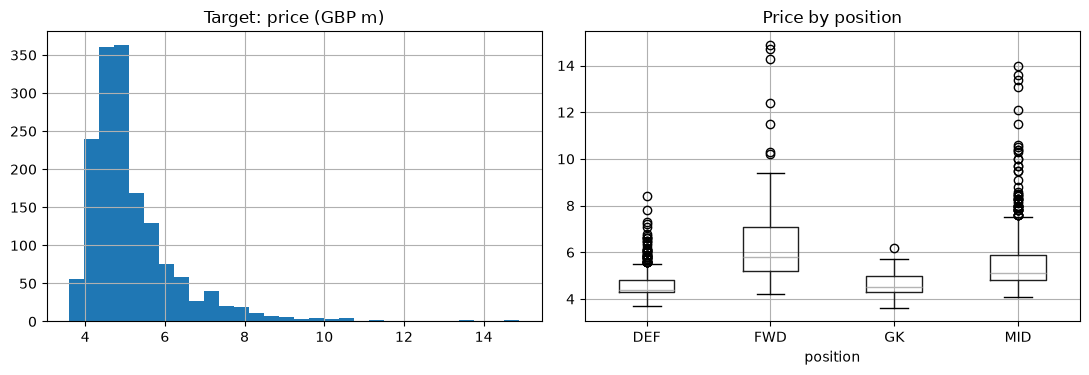

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
features['price_m'].hist(bins=30, ax=ax[0])
ax[0].set_title('Target: price (GBP m)')
features.boxplot(column='price_m', by='position', ax=ax[1])
ax[1].set_title('Price by position')
plt.suptitle(''); plt.tight_layout()

## 2. Season-held-out cross-validation

Each fold is scored on a season the model never trained on. The mean-price baseline is the bar to clear.

In [12]:
cross_validate_by_season(features).round(3)

,mae_m,r2
estimator,,
gbr,0.479,0.628
ridge,0.494,0.635
linear,0.497,0.635
baseline_mean,0.831,-0.003


## 3. Predicted vs actual price (linear model)

Refit on every season, then look at the fit and the residuals. Points far above the diagonal are players the model prices higher than the market: its underpriced picks.

Text(0.5, 1.0, 'Linear model: predicted vs actual')

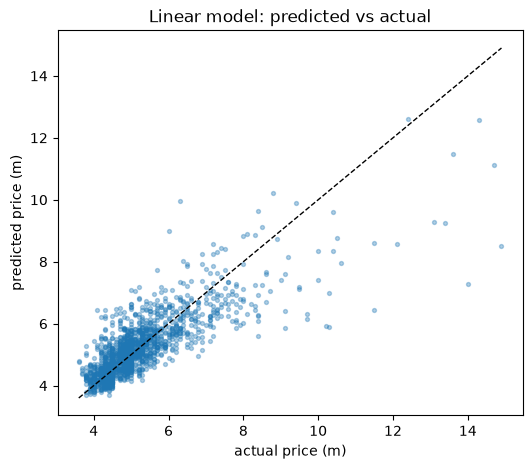

In [13]:
model = ValueModel().fit(features)
scored = model.score_frame(features)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(scored['price_m'], scored['pred_m'], s=8, alpha=0.35)
lims = [scored['price_m'].min(), scored['price_m'].max()]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('actual price (m)'); ax.set_ylabel('predicted price (m)')
ax.set_title('Linear model: predicted vs actual')

In [14]:
cols = ['name', 'season', 'position', 'price_m', 'pred_m', 'value_m']
print('Most underpriced (historical seasons):')
display(scored.head(10)[cols].round(2))
print('Most overpriced (historical seasons):')
display(scored.tail(10)[cols].round(2))

Most underpriced (historical seasons):


,name,season,position,price_m,pred_m,value_m
0,Cole Palmer,2023-24,MID,6.3,9.95,3.65
1,Kieran Trippier,2022-23,DEF,6.0,9.00,3.00
2,Alejandro Garnacho,2022-23,MID,4.1,6.45,2.35
3,Rodrigo Muniz Carvalho,2023-24,FWD,4.3,6.44,2.14
4,Deniz Undav,2022-23,FWD,5.0,7.08,2.08
5,Kaoru Mitoma,2022-23,MID,5.7,7.73,2.03
6,Jacob Murphy,2022-23,MID,4.2,6.22,2.02
7,João Pedro Junqueira de Jesus,2023-24,FWD,5.2,7.19,1.99
8,Marc Guéhi,2025-26,DEF,5.1,7.04,1.94
9,Andreas Hoelgebaum Pereira,2022-23,MID,4.3,6.23,1.93


Most overpriced (historical seasons):


,name,season,position,price_m,pred_m,value_m
1598,Kevin De Bruyne,2022-23,MID,12.1,8.58,-3.52
1599,Raheem Sterling,2022-23,MID,9.7,6.16,-3.54
1600,Erling Haaland,2025-26,FWD,14.7,11.11,-3.59
1601,Mohamed Salah,2022-23,MID,13.1,9.28,-3.82
1602,Mohamed Salah,2023-24,MID,13.4,9.24,-4.16
1603,Cristiano Ronaldo dos Santos Aveiro,2022-23,FWD,10.2,5.94,-4.26
1604,Alexander Isak,2025-26,FWD,10.3,5.91,-4.39
1605,Son Heung-min,2022-23,MID,11.5,6.44,-5.06
1606,Erling Haaland,2024-25,FWD,14.9,8.52,-6.38
1607,Mohamed Salah,2025-26,MID,14.0,7.26,-6.74


## 4. Does the value signal pick better squads?

Walk-forward: fit on earlier seasons, draft the top 20 of each ranking from the prior season, and score them on the *next* season's points per million of acquisition cost. Higher is better.

In [15]:
walk_forward_backtest(history, top_n=20).round(2)

,2023-24,2024-25,2025-26,mean
fpl_form,18.63,18.27,19.76,18.89
model_value,16.81,19.83,17.49,18.04
points_per90,16.16,17.48,11.39,15.01
cheapest,14.10,11.96,15.88,13.98


## 5. Current player pool

Live players scored on a blend of this season's form and their most recent completed season's, weighted by minutes played so far. Players with no personal PL history (new signings, promoted-team players, academy graduates) get a position-average prediction instead of being dropped -- flagged via `has_history` since it's a much weaker signal. Unavailable players (injured/suspended/unregistered) are flagged via `available` rather than silently ranked.

In [16]:
live_scored = model.score_frame(attach_history_features(live, history))
live_cols = ['name', 'position', 'price_m', 'pred_m', 'value_m', 'total_points', 'status']
print(f'{len(live_scored)} of {len(live)} live players scored')

no_history = ~live_scored['has_history']
print(f'{no_history.sum()} have no personal PL history and are priced on a position average only')

unavailable = ~live_scored['available']
print(f'{unavailable.sum()} are currently injured, suspended, or unregistered (status != "a")')

# Primary signal: players with their own track record who are actually available.
trusted = live_scored[live_scored['has_history'] & live_scored['available']]
print('\nModel thinks these are underpriced (own history, available):')
display(trusted.head(15)[live_cols].round(2))
print('Model thinks these are overpriced (own history, available):')
display(trusted.tail(15)[live_cols].round(2))

print('\nUnavailable players that would otherwise rank in the top 15 underpriced (buyer beware):')
display(live_scored[unavailable].sort_values('value_m', ascending=False).head(15)[live_cols].round(2))

print('\nNo personal history -- position-average price only, treat as speculative:')
display(live_scored[no_history].sort_values('value_m', ascending=False).head(15)[live_cols].round(2))

667 of 667 live players scored
289 have no personal PL history and are priced on a position average only
201 are currently injured, suspended, or unregistered (status != "a")

Model thinks these are underpriced (own history, available):


,name,position,price_m,pred_m,value_m,total_points,status
1,Riccardo Calafiori,DEF,5.8,8.06,2.26,29,a
5,Maxim De Cuyper,DEF,4.9,6.59,1.69,38,a
6,Dominic Calvert-Lewin,FWD,6.0,7.63,1.63,22,a
10,David Brooks,MID,5.0,6.40,1.40,3,a
14,Pascal Groß,MID,5.8,7.12,1.32,47,a
17,Martin Dubravka,GK,4.0,5.29,1.29,0,a
22,Ezri Konsa Ngoyo,DEF,4.6,5.82,1.22,12,a
28,Eddie Nketiah,FWD,5.5,6.67,1.17,8,a
31,Thierno Barry,FWD,5.6,6.75,1.15,20,a
32,Lukas Nmecha,FWD,5.4,6.52,1.12,7,a


Model thinks these are overpriced (own history, available):


,name,position,price_m,pred_m,value_m,total_points,status
646,James Hill,DEF,5.5,4.43,-1.07,12,a
647,Jack Grealish,MID,6.5,5.42,-1.08,6,a
648,Mohammed Kudus,MID,6.5,5.39,-1.11,7,a
650,Matheus Nunes,DEF,5.9,4.77,-1.13,11,a
651,Morgan Gibbs-White,MID,8.0,6.83,-1.17,28,a
652,Jarrad Branthwaite,DEF,5.5,4.33,-1.17,27,a
655,Omar Marmoush,FWD,7.0,5.67,-1.33,8,a
656,Jurriën Timber,DEF,6.5,5.08,-1.42,1,a
657,Alexander Isak,FWD,9.1,7.61,-1.49,33,a
659,Antoine Semenyo,MID,8.4,6.81,-1.59,33,a



Unavailable players that would otherwise rank in the top 15 underpriced (buyer beware):


,name,position,price_m,pred_m,value_m,total_points,status
0,João Pedro Junqueira de Jesus,FWD,7.7,10.40,2.70,33,d
2,Chido Obi,FWD,4.5,6.28,1.78,0,u
8,Dane Scarlett,FWD,4.5,6.00,1.50,0,u
9,Kaye Furo,FWD,4.5,5.99,1.49,0,i
13,Sean Neave,FWD,4.5,5.82,1.32,0,u
15,Mateo Joseph Fernández-Regatillo,FWD,4.5,5.80,1.30,0,i
20,Marc Guiu Paz,FWD,5.0,6.23,1.23,0,u
21,Emmanuel Emegha,FWD,5.0,6.22,1.22,0,i
23,Divine Mukasa,MID,4.5,5.71,1.21,0,u
27,Enis Destan,FWD,4.5,5.67,1.17,0,u



No personal history -- position-average price only, treat as speculative:


,name,position,price_m,pred_m,value_m,total_points,status
2,Chido Obi,FWD,4.5,6.28,1.78,0,u
3,Shumaira Mheuka,FWD,4.5,6.25,1.75,0,a
4,Jayden Danns,FWD,4.5,6.23,1.73,0,a
7,Jonah Kusi-Asare,FWD,4.5,6.11,1.61,0,a
8,Dane Scarlett,FWD,4.5,6.00,1.50,0,u
9,Kaye Furo,FWD,4.5,5.99,1.49,0,i
11,Juan Angulo,FWD,4.5,5.84,1.34,0,a
12,Sindre Walle Egeli,FWD,4.5,5.83,1.33,1,a
13,Sean Neave,FWD,4.5,5.82,1.32,0,u
15,Mateo Joseph Fernández-Regatillo,FWD,4.5,5.80,1.30,0,i


## Notes

- Linear and ridge sit on top of each other; GBR is marginally ahead on MAE. Keep linear as the default for interpretability.
- Premium players (Haaland, Salah, Bruno) always read as 'overpriced': a linear model on per-90 counting stats can't see the captaincy / ownership / fixture-proof premium. Documented in `PROJECT.md`.
- The value signal beats raw FPL form only narrowly in the backtest.
- Done: live scoring blends this-season form with last season's (weighted by minutes played so far); carries FPL's `status`/`chance_of_playing_next_round` through as an `available` flag; falls back to a position average (flagged `has_history=False`) instead of dropping players with no personal PL history; adds team strength (z-scored within each season/source, current club only, never blended); and adds ownership (`selected_by_percent`, current value only, never blended).
- Ownership result: partially confirms the premium-player hypothesis. Haaland's residual shrank from -6.85 to -3.85 and Bruno's from -4.22 to -2.74 once ownership was added -- real signal recovered, not full leakage (residuals didn't collapse to ~0, which would mean the model was just parroting price back). CV: gbr MAE 0.500 -> 0.479, R² 0.599 -> 0.628.
- Team strength result: fixed the live-vs-historical scale mismatch by z-scoring within each season/source independently ("how strong relative to its 19 rivals that season"). CV: gbr MAE 0.542 -> 0.500, R² 0.551 -> 0.599.
- Tried and rejected: separate models per position -- tested via season-held-out CV and every position got *worse* (e.g. MID MAE 0.596->0.639, R² 0.473->0.369) versus the pooled model with position as a feature. Not worth the added complexity.
- Known tradeoff of the position-average fallback: ~13 minimum-priced academy fringe players can tie for the same predicted value, since the model has nothing to tell them apart beyond position and price floor. The current player-pool section keeps them out of the primary underpriced/overpriced lists (filtered to `has_history & available`) and surfaces them separately as speculative.
- Dropped: predicting forward points directly instead of price. Would need a new data source (per-gameweek history) and a new rolling-feature pipeline -- decided not worth it for now; the price-value signal plus the ownership/team-strength features cover most of the same ground.